In [29]:
from numpy import zeros
from numpy.random import normal, randint, choice, rand
from pandas import DataFrame, date_range

N_STEPS = 240
PROPABILITY = 0.06
PAUSE_TIME_AFTER_MOTIV = 20
MOTIV_LEN = 5

timestamps = date_range(start="2026-04-30", periods=N_STEPS, freq=f'1s')


def generate_motive():
    length = randint(MOTIV_LEN*0.5, MOTIV_LEN*2.5)
    return length, normal(2, 0.05, length)


sensor = []
current_step = 0
while current_step < N_STEPS:
    if rand() <= PROPABILITY:
        length, run = generate_motive()
        sensor += list(run) + [0]*PAUSE_TIME_AFTER_MOTIV
        current_step += length + PAUSE_TIME_AFTER_MOTIV
    else:
        sensor.append(0)
        current_step += 1

# Sensor mit Rauschen überlagern
sensor += normal(0,0.22,len(sensor))

# Sensor auf vorgegebene Länge reduzieren
sensor = sensor[:240]

# Daten speichern und exportieren
df = DataFrame({
    "timestamp": timestamps,
    "sensor": sensor
})

filename = f"motiv_{N_STEPS}.csv"
df.to_csv(filename, index=False)
print(f"Exported data to {filename}")

Exported data to motiv_240.csv


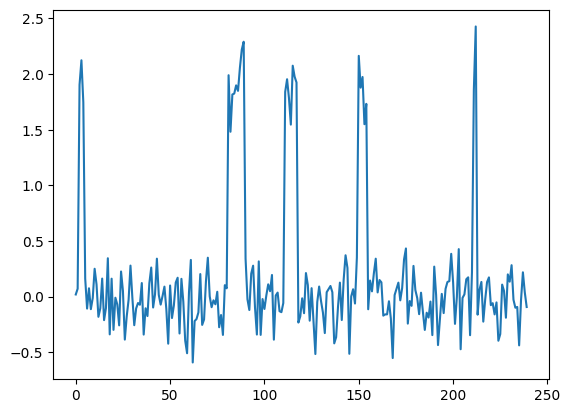

In [30]:
from matplotlib import pyplot as plt
plt.plot(sensor)